# Titanic : Machine Learning From Disaster

In [1]:
from IPython.display import Image
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/5095eabce4b06cb305058603/5095eabce4b02d37bef4c24c/1352002236895/100_anniversary_titanic_sinking_by_esai8mellows-d4xbme8.jpg")

Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/t/5090b249e4b047ba54dfd258/1351660113175/TItanic-Survival-Infographic.jpg?format=1500w")

# I describe below the process that i followed



 1. EXPLORATORY DATA ANALYSIS

   - 1.1 Data Extraction
   
   - 1.2 Overview
  
   - 1.3 Descriptive statistics
  
   - 1.4 Data visualisation
   

 2. Feature Engineering

   - 2.1 Filling missing Values
  
   - 2.2 Binning the categorical features
  
   - 2.3 Creating New Features
   
   - 2.4 Removing irrelevant variables
   
   - 2.4 Creating dummy variables
   
  

 3. Pre-Modeling Tasks


   -  3.1 Defining Features in Training/Test Set
   
   -  3.2 Splitting the dataset
   
   -  3.3 Scaling the dataset
   

 4. Modeling
  
   - Logistic Regression
   
   - Evaluate the model performance
     
     - Confusion Matrix
     - Accuracy Score
     - Precision Score
     - Recall Score
     - AUC & ROC Curve
     
   - GaussianNB Model
   - Logistic Regression Model
   - Support Vector Machine 
   - KNeighbors Model
   - Decision Tree Model
   - Random Forest Model
   - XGB Classifier
   - Voting Classifier
   
    
 5. Model Tuning using Grid Search
 

 6. Ensemble Modeling

   - Bagging Classifier
   
   - Boosting Classifier
    - Ada Boost Classifier
    - Gradient Boosting classifier
    
   - XGB Classifier
   
   - Extra Trees Classifier
   
   - Gaussian Process NB
   
   - Voting Classifier
   

7. Predictions


- Useful resources
  

# 1. EXPLORATORY DATA ANALYSIS


# 1.1 Data Extraction

This step it's about installing packages, and the best way is to install the conda distribution that contains them all.

Then, we import the relevant libraries to help us manipulate the data.

Numpy for linear algebra and matrices.

Pandas for data analysis,manipulation tool and data processing.

Matplotlib and seaborn for the visualization of the data set.

Sklearn is a collection of machine learning algorithms and predictive modeling

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Data visualization

import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set()


# Pre-Modeling Tasks


from sklearn import preprocessing

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler    # to scaling our data 

from sklearn.model_selection import train_test_split  #to create validation data set

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import learning_curve




 # Measure of Performance
    
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv


## 1.2 Viewing Data Set

In this step we start by loading our data and the data set has split into two groups:

-Training set: (train_csv) ; includes our variable target(dependent variable),passenger survival along with other features (Sex, Age, Parch,Sibsp, fare, cabin, Ticket)

-Test et( test_csv);  should be used to see how well our model performs on unseen data. When we say unseen data, we mean that the algorithm or machine learning models have no relation to the test data. We do not want to use any part of the test data in any way to modify our algorithms; Which are the reasons why we clean our test data and train data separately

In [3]:
# lets load the data set

train = pd.read_csv("../input/titanic/train.csv")
test  = pd.read_csv("../input/titanic/test.csv")



In [4]:
train.shape

(891, 12)

In [5]:
test.shape

(418, 11)


-PassengerId is the unique id of the row and it doesn't have any effect on target

-Survived is the target variable we are trying to predict (0 or 1):
1 = Survived
0 = Not Survived

-Pclass (Passenger Class) is the socio-economic status of the passenger and it is a categorical ordinal feature which has 3 unique values (1, 2 or 3):
1 = Upper Class
2 = Middle Class
3 = Lower Class

-Name, Sex and Age are self-explanatory.

-SibSp is the total number of the passengers' siblings and spouse.

-Parch is the total number of the passengers' parents and children.

-Ticket is the ticket number of the passenger.

-Fare is the passenger fare.

-Cabin is the cabin number of the passenger.

-Embarked is port of embarkation and it is a categorical feature which has 3 unique values (C, Q or S):
C = Cherbourg
Q = Queenstown
S = Southampton

In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.shape

(891, 12)

In [8]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
test.shape

(418, 11)

## 1.3 Descriptive Statistics

The next step we'll do some descriptive statistics, this one helps us to describe and understand the features of a specific data by giving short 

summaries about the sample and measures of the data 


In [10]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### Checking for the correlation

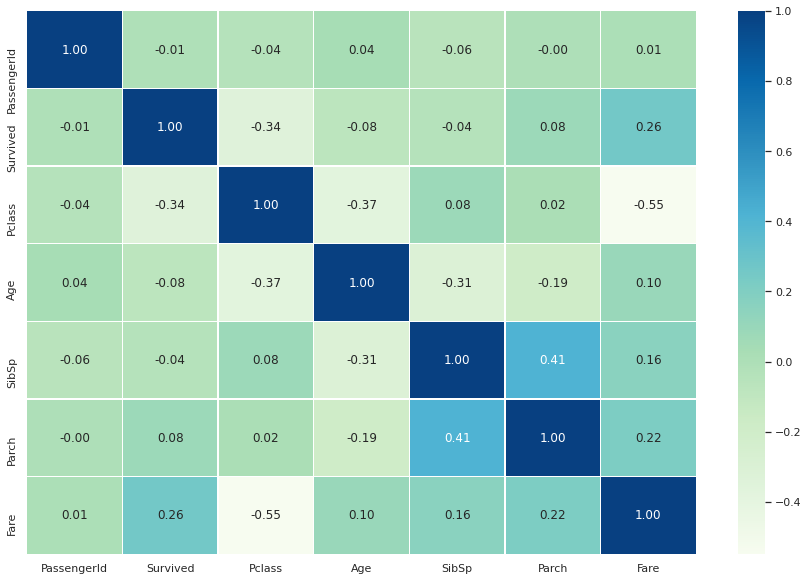

In [11]:
# Correlation Map

# Display the negative and postive correlation between variables

train.corr
f,ax = plt.subplots(figsize=(15,10))
sns.heatmap(train.corr(), annot =True, linewidth =".5", fmt =".2f", cmap='GnBu')
plt.show()



#figsize - image size
#data.corr() - Display positive and negative correlation between columns
#annot=True -shows correlation rates
#linewidths - determines the thickness of the lines in between
#cmap - determines the color tones we will use
#fmt - determines precision(Number of digits after 0)
#if the correlation between the two columns is close to 1 or 1, the correlation between the two columns has a positive ratio.
#if the correlation between the two columns is close to -1 or -1, the correlation between the two columns has a negative ratio.
#If it is close to 0 or 0 there is no relationship between them.

## 1.4 Data Visualization

### - Survived feature

Distribution of survivals : 1 is for survival and 0 is for not

In [12]:
train["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

## - Sex feature vs Survived feature

Percentage of females who survived : 74.20382165605095
Percentage of males who survived : 18.890814558058924


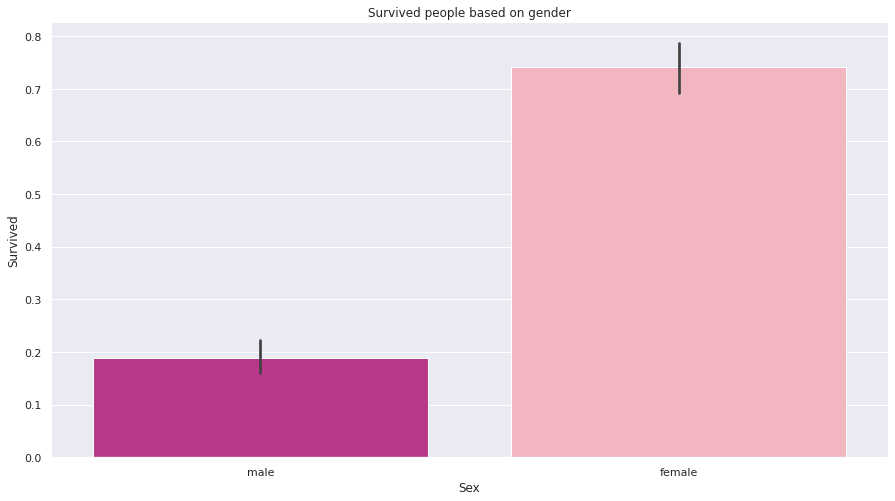

In [13]:
# BarPlot

# Set the width and the height of the figure
plt.figure(figsize=(15,8))

# Add the title
plt.title("Survived people based on gender")

# Draw a barplot of survival people by sex
sns.barplot(x="Sex",y="Survived", data =train,palette=('RdPu_r'))

# Print percentage of males vs females that are survived 
print("Percentage of females who survived :",  train["Survived"][train["Sex"] == 'female'].value_counts(normalize = True)[1]*100)
print ("Percentage of males who survived :",  train["Survived"][train["Sex"]==  'male'].value_counts(normalize= True)[1]*100)

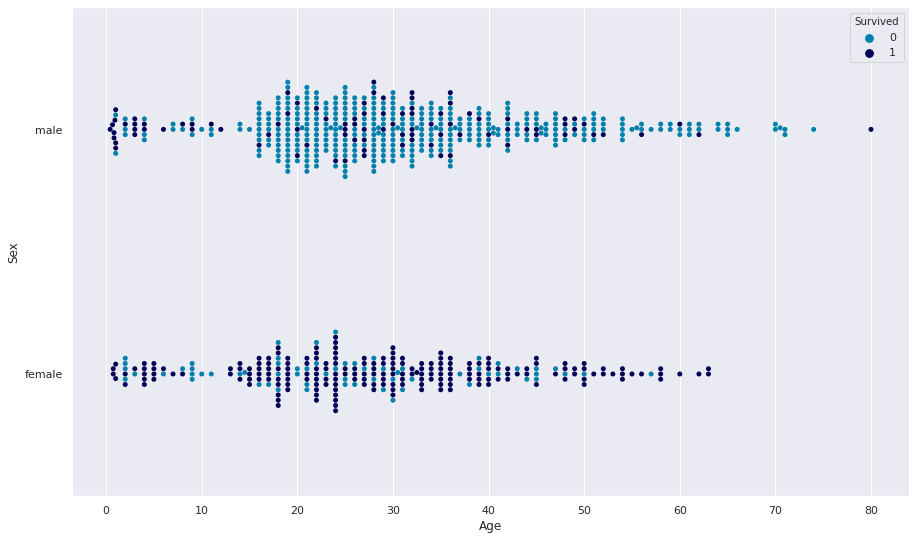

In [14]:
# swarmplot

plt.figure(figsize=(15,9))

sns.swarmplot(x=train['Age'], y=train['Sex'], hue='Survived', data =train, palette= 'ocean_r')

According to this graph, we can notice that womens are more likely to survive

## - PARCH feature vs Survived feature

<function matplotlib.pyplot.show(*args, **kw)>

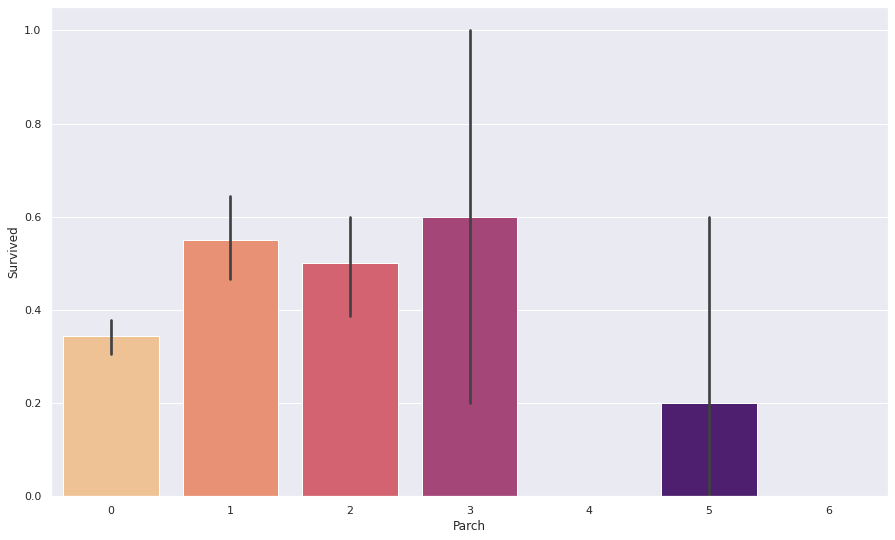

In [15]:
# Barplot

# Set the width and the height of the figure
plt.figure(figsize=(15,9))
sns.barplot(x="Parch", y="Survived", data = train, palette='magma_r')
plt.show

People with less than four parents or childrens aboard more likely to survive

## - SibSp Feature 

<function matplotlib.pyplot.show(*args, **kw)>

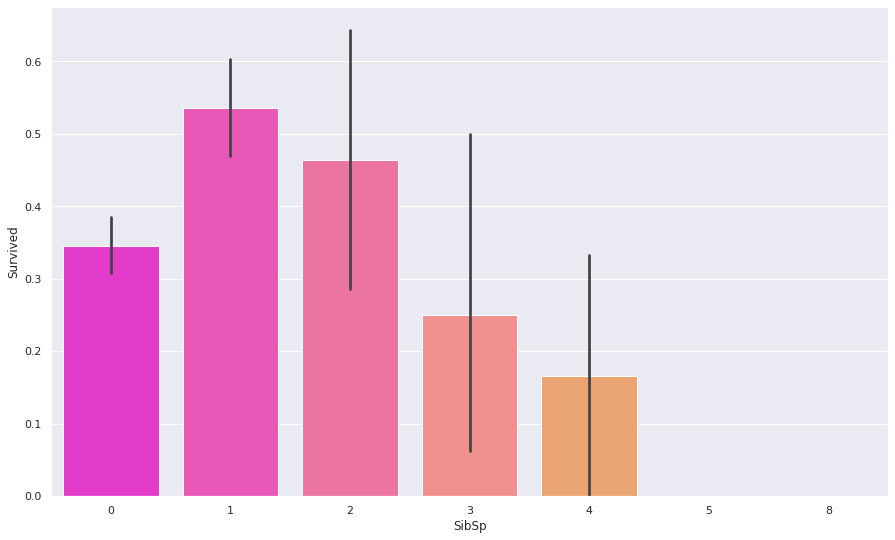

In [16]:
# Barplot

plt.figure(figsize=(15,9))
sns.barplot(x="SibSp", y="Survived", data=train, palette='spring')
plt.show

People with SibSp or spouses were less likely to survive, therefore people with no children were more less likely to survived than those with one children or two.

## - Embarked and fare features

Let's now see how the embarkation site affects the survival.

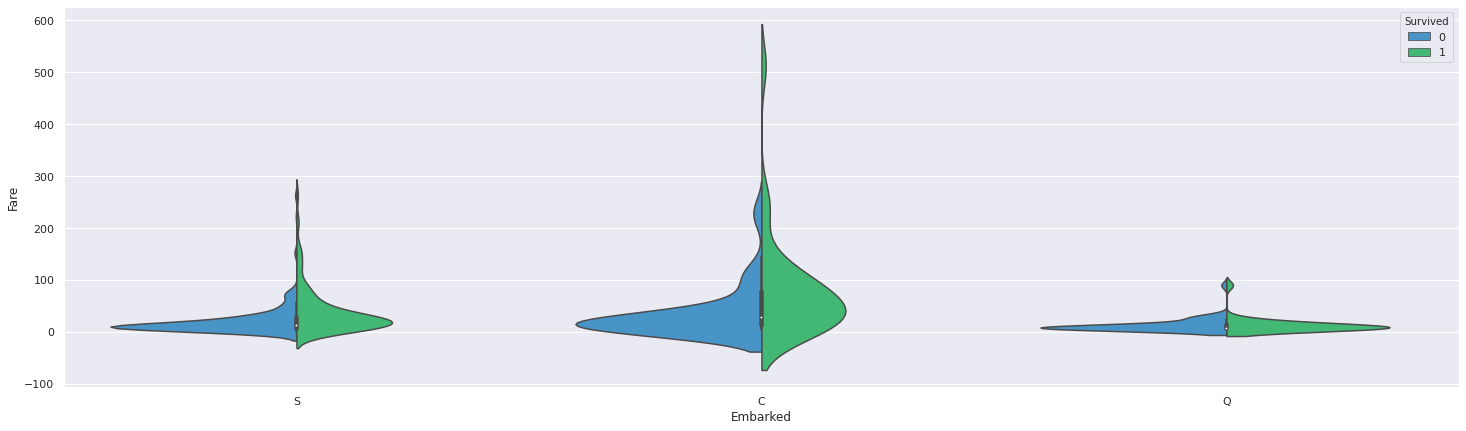

In [17]:
# Violinplot

fig = plt.figure(figsize=(25, 7))
sns.violinplot(x ="Embarked", y ="Fare", hue ="Survived", data=train, split =True , palette = {0: "#3498db", 1:"#2ecc71"});

## - Passenger Class

To look at the correlation between passenger class and survival statistics I would plot a countplot.

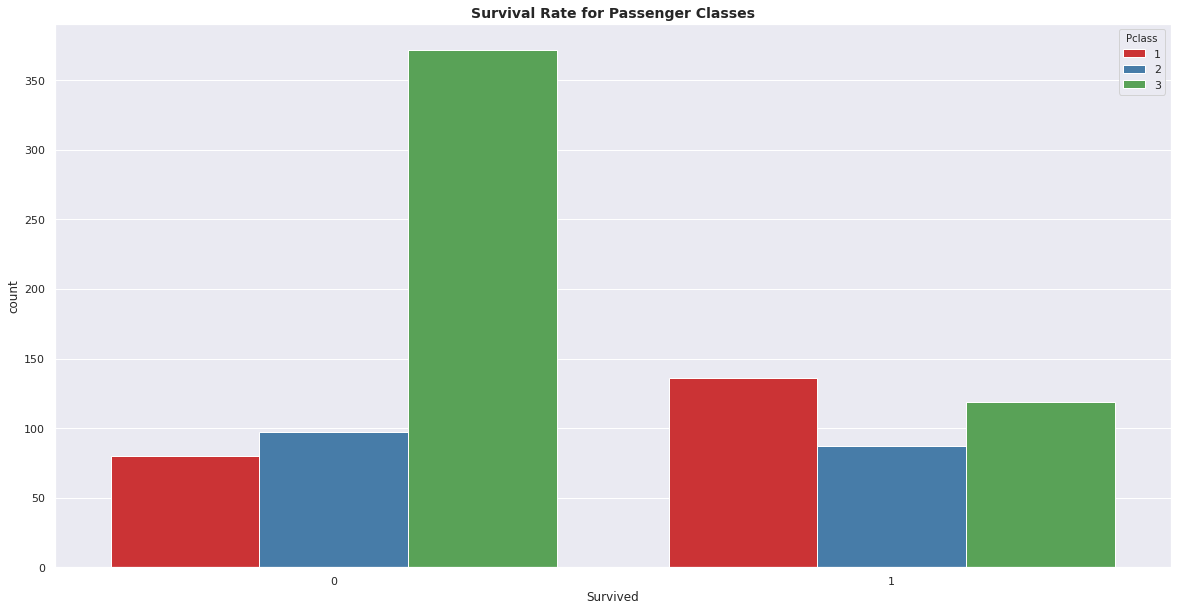

In [18]:
# Subplot

fig, ax = plt.subplots(figsize = (20,10))
ax = sns.countplot(x = 'Survived', hue = 'Pclass', data = train, palette = 'Set1')
ax.set_xlabel('Survived')
ax.set_title('Survival Rate for Passenger Classes', fontsize = 14, fontweight='bold');

# 2. Feature Engineering

A critical part of the success of a Machine Learning Project is Feature Engineering. 

Feature Engineering is a process of transforming the data into data which is easier to interept and also, to increase the predictive power of learning algorithm

In Feature Engineering we will create a new features that could improve predictions such as if the passenger is alone or not,
and combining existing features to produce a more useful one, and dropping the columns doesn't improve predictions.

So Feature Engineering have two goals:

- Preparing the proper input dataset, compatible with the machine learning algorithm requirements.
- Improving the performance of a machine learning model 

In this section, we'll be doing four things.

Cleaning : we'll fill in missing values.

Removing : we'll removing the less relevant variables that doesn't improve predictions, as "Ticket" and "Cabin", because they contains many null values both in training and test datatest. Therefore, "PassengerId" may be also dropped from training dataset as it does not contribute to survival

Data Binning : we'll transform  categorical features into numerical as "Sex", "Embarked"

Creating New Varibles: we'll create new variable called "FamilySize" based on "Parch" feature and "SibSp" feature.
                       we'll create "IsAlone" feature to check if a person traveling alone is more likely to survived or died
                       We may want to engineer the Name feature to extract Title as a new feature, to determine if it played a role in survival.

##### Checking for missing values

In [19]:
# let's take more detaild look of what data is actually missing 
total = train.isnull().sum().sort_values(ascending=False)
percent_1 = train.isnull().sum()/train.isnull().count()*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
missing_data.head(5)

,Total,%
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
Fare,0,0.0
Ticket,0,0.0


A critical part of the success of a Machine Learning Project is Feature Engineering

In [20]:
train.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

In [21]:
test.isnull().any()

PassengerId    False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare            True
Cabin           True
Embarked       False
dtype: bool

## 2.1 Filling missing Values

In [22]:
# Processing Age


train["Age"] = train["Age"]. fillna(train["Age"].mean())

test["Age"]  = test["Age"] . fillna(test["Age"].mean())

In [23]:
# Processing Fare

test["Fare"] = test ["Fare"]. fillna(test["Fare"].mean())

## 2.2 Bining Categorical variables

In [24]:
# Processing Sex


Before we fit the data into a machine learning algorithm, there is a step very crucial is that we make sure to encode categorical variables correctly

We will change Sex to binary, as either 1 for female or 0 for male. We do the same for Embarked. We do this same process on both the training and testing set to prepare our data for Machine Learning.

In [25]:
train.loc[train["Sex"] == "male" , "Sex"] = 0
train.loc[train["Sex"] == "female","Sex"] = 1



test.loc[test["Sex"] == "male", "Sex"] = 0
test.loc[test["Sex"] == "female", "Sex"] = 1


In [26]:
# Processing Embarked

In [27]:
train.loc[train["Embarked"] == "S", "Embarked"] = 0
train.loc[train["Embarked"] == "C", "Embarked"] = 1
train.loc[train["Embarked"] == "Q", "Embarked"] = 2


test.loc[test["Embarked"]  == "S", "Embarked"] = 0
test.loc[test["Embarked"]  == "C", "Embarked"] = 1
test.loc[test["Embarked"]  == "Q", "Embarked"] = 2

In [28]:
train["Embarked"].fillna("S", inplace = True)

## 2.3 Creating New Features

Then, introducing new features as Family size (to join these Parch and SibSp)

In [29]:
train["FamSize"] = train["SibSp"] + train["Parch"] + 1
test["FamSize"]  =  test["SibSp"] + test["Parch"]  + 1

The next option is to cerate IsAlone feature to check wheter a person traveling alolne is more likely to survived or died

In [30]:
train["IsAlone"] = train.FamSize.apply(lambda x: 1 if x == 1 else 0)
test["IsAlone"]  = test.FamSize.apply( lambda x: 1 if x == 1 else 0)

In [31]:
# Extraction the passengers titles

If we have a quick look in the names of the passengers we will notice that each name has a title in it, so it can be a useful information for our analyze. Therefore we can extract this title from the name of each passenger and then encode it like we did for Sex and Embarked.

In [32]:
for name in train["Name"]:
    train["Title"] = train["Name"].str.extract("([A-Za-z]+)\.",expand=True)
    
for name in test["Name"]:
    test["Title"] = test["Name"].str.extract("([A-Za-z]+)\.",expand=True)
    
title_replacements = {"Mlle": "Other", "Major": "Other", "Col": "Other", "Sir": "Other", "Don": "Other", "Mme": "Other",
          "Jonkheer": "Other", "Lady": "Other", "Capt": "Other", "Countess": "Other", "Ms": "Other", "Dona": "Other", "Rev": "Other", "Dr": "Other"}

train.replace({"Title": title_replacements}, inplace=True)
test.replace({"Title": title_replacements}, inplace=True)

train.loc[train["Title"] == "Miss", "Title"] = 0
train.loc[train["Title"] == "Mr", "Title"] = 1
train.loc[train["Title"] == "Mrs", "Title"] = 2
train.loc[train["Title"] == "Master", "Title"] = 3
train.loc[train["Title"] == "Other", "Title"] = 4

test.loc[test["Title"] == "Miss", "Title"] = 0
test.loc[test["Title"] == "Mr", "Title"] = 1
test.loc[test["Title"] == "Mrs", "Title"] = 2
test.loc[test["Title"] == "Master", "Title"] = 3
test.loc[test["Title"] == "Other", "Title"] = 4

In [33]:
print(set(train["Title"]))

{0, 1, 2, 3, 4}


In [34]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamSize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,2,0,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,2,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,1,1


In [35]:
train['Age'] = train['Age'].astype(int)
train.loc[ train['Age'] <= 11, 'Age'] = 0
train.loc[(train['Age'] > 11) & (train['Age'] <= 18), 'Age'] = 1
train.loc[(train['Age'] > 18) & (train['Age'] <= 22), 'Age'] = 2
train.loc[(train['Age'] > 22) & (train['Age'] <= 27), 'Age'] = 3
train.loc[(train['Age'] > 27) & (train['Age'] <= 33), 'Age'] = 4
train.loc[(train['Age'] > 33) & (train['Age'] <= 40), 'Age'] = 5
train.loc[(train['Age'] > 40) & (train['Age'] <= 66), 'Age'] = 6
train.loc[ train['Age'] > 66, 'Age'] = 6

# let's see how it's distributed train_df['Age'].value_counts()

In [36]:
test['Age'] = test['Age'].astype(int)
test.loc[test['Age']<= 11, 'Age'] =0
test.loc[(test['Age'] > 11)& (test['Age'] <= 18), 'Age'] = 1
test.loc[(test['Age'] > 18) & (test['Age'] <= 22), 'Age'] = 2
test.loc[(test['Age'] > 22) & (test['Age'] <= 27), 'Age'] = 3
test.loc[(test['Age'] > 27) & (test['Age'] <= 33), 'Age'] = 4
test.loc[(test['Age'] > 33) & (test['Age'] <= 40), 'Age'] = 5
test.loc[(test['Age'] > 40) & (test['Age'] <= 66), 'Age'] = 6
test.loc[ test['Age'] > 66, 'Age'] = 6

## 2.4 Removing irrelevant variables

the next step is dropping the less relevant features beacuse, The problem with less important features is that they create more noice and actually take over the importance of real features like Sex and Pclass.

In [37]:
features_drop = ['Ticket', 'SibSp', 'Parch', "Name", "Cabin", "Fare"]
train = train.drop(features_drop, axis=1)
test = test.drop(features_drop, axis=1)
train = train.drop(['PassengerId'], axis=1)

## 2.5 Creating dummy variables

In [38]:
train = pd.get_dummies(train, columns=['Pclass','Sex','Embarked','Title'], 
                       drop_first=False)
test = pd.get_dummies(test, columns=['Pclass','Sex','Embarked','Title'],
                      drop_first=False)

# 3 Pre-Modeling Tasks

### 3.1 Separating the independant and the dependant variable

In [39]:
X = train.drop('Survived', axis=1)
y = train['Survived']

X.shape,y.shape

((891, 17), (891,))

### 3.2 Splitting the training data 


In [40]:

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = .33, random_state=0)

In [41]:
len(X_train)

596

In [42]:
len(X_test)

295

### 3.3 Feature Scaling

Feature scaling is a method used to standardize the range of independent variables or features of data. Scaling the data is very important to boost the score.

In [43]:
std_scale = StandardScaler()

## transforming "train_x"
X_train = std_scale.fit_transform(X_train)
## transforming "test_x"
X_test = std_scale.transform(X_test)


We can see that all variables in both datasets now have values in the desired range of 0 to 1.

# 4- Modeling 

In this part we'll try differents models of Machine learning: Logistic Regression, Random Forest, Support Vector Machine, Lsvm, Decision tree, GaussianNB Medel and KNeighbors Model


In [44]:
from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier



#Ensemble Modeling 

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.ensemble import ExtraTreesClassifier

import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier

from sklearn.ensemble import VotingClassifier


#### logistic Regression

In [45]:
logreg= LogisticRegression()

logreg.fit(X_train,y_train)

pred_logreg = logreg.predict(X_test)

### - Evaluating the performance of the model

# Confusion Matrix

In [46]:
pd.DataFrame(confusion_matrix(y_test, pred_logreg),\
             columns= ["Predicted Not Survived", "Predicted Survived"],\
             index = ["Not-Survived", "Survived"])


,Predicted Not Survived,Predicted Survived
Not-Survived,155,29
Survived,22,89


# Accuracy Score

In [47]:
acc_score_logreg= accuracy_score(y_test, pred_logreg)
print(acc_score_logreg)

0.8271186440677966


# precision Score

In [48]:
precision_score_logreg = precision_score(y_test,pred_logreg)
print(precision_score_logreg)

0.7542372881355932


# Recall Score

In [49]:
recall_score_logreg = recall_score(y_test,pred_logreg)
print(recall_score_logreg)

0.8018018018018018


# AUC & ROC Curve

0.867508813160987


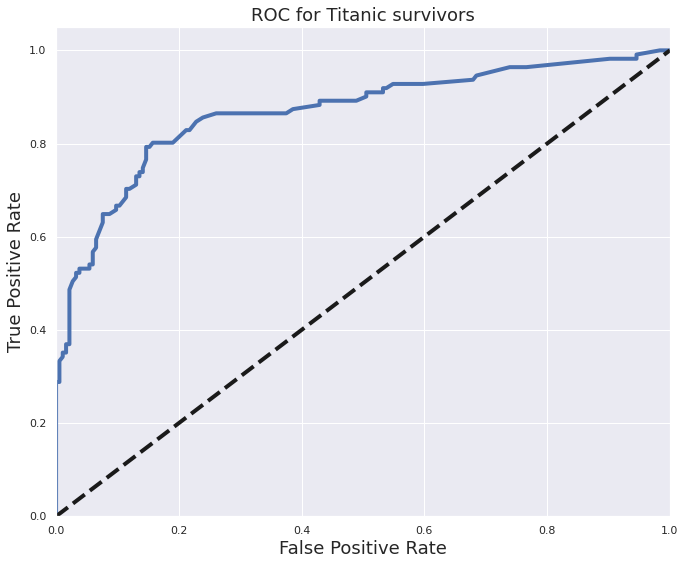

In [50]:
from sklearn.metrics import roc_curve, auc
#plt.style.use('seaborn-pastel')
y_score = logreg.decision_function(X_test)

FPR, TPR, _ = roc_curve(y_test, y_score)
ROC_AUC = auc(FPR, TPR)
print (ROC_AUC)

plt.figure(figsize =[11,9])
plt.plot(FPR, TPR, label= 'ROC curve(area = %0.2f)'%ROC_AUC, linewidth= 4)
plt.plot([0,1],[0,1], 'k--', linewidth = 4)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate', fontsize = 18)
plt.ylabel('True Positive Rate', fontsize = 18)
plt.title('ROC for Titanic survivors', fontsize= 18)
plt.show()

In [51]:
gnb = GaussianNB()

cv = cross_val_score(gnb, X_train,y_train, cv=5)

print(cv)
print(cv.mean())

[0.71666667 0.76470588 0.76470588 0.69747899 0.76470588]
0.7416526610644258


In [52]:
log_reg = LogisticRegression(max_iter = 2000)

cv = cross_val_score(log_reg, X_train,y_train, cv=5)


print(cv)
print(cv.mean())

[0.81666667 0.81512605 0.82352941 0.83193277 0.87394958]
0.8322408963585435


In [53]:
dt = DecisionTreeClassifier(random_state= 1)

cv= cross_val_score(dt, X_train,y_train,cv=5)

print(cv)
print(cv.mean())

[0.76666667 0.78151261 0.76470588 0.81512605 0.81512605]
0.788627450980392


In [54]:
knn = KNeighborsClassifier(n_neighbors=3)

cv= cross_val_score(knn, X_train,y_train, cv=5)

print(cv)
print(cv.mean())

[0.75833333 0.78151261 0.81512605 0.81512605 0.82352941]
0.7987254901960783


In [55]:
rf_clf = RandomForestClassifier(random_state= 1)

cv = cross_val_score(rf_clf, X_train,y_train, cv=5)

print(cv)
print(cv.mean())

[0.78333333 0.81512605 0.79831933 0.80672269 0.81512605]
0.8037254901960784


In [56]:
svc = SVC(probability = True)

cv = cross_val_score(svc, X_train,y_train, cv=5)

print(cv)
print(cv.mean())

[0.79166667 0.83193277 0.80672269 0.79831933 0.86554622]
0.8188375350140056


In [57]:
xgb= XGBClassifier(random_state=1)

cv = cross_val_score(xgb, X_train,y_train, cv= 5)

print(cv)
print(cv.mean())


[0.76666667 0.82352941 0.79831933 0.81512605 0.82352941]
0.8054341736694678


In [58]:
voting_clf = VotingClassifier(estimators=[('gnb',gnb),('log_reg',log_reg),('dt',dt),('knn',knn),('rf_clf',rf_clf),('svc',svc),('xgb',xgb) ], voting='soft', n_jobs=4)


In [59]:
cv = cross_val_score(voting_clf,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.775      0.83193277 0.78151261 0.80672269 0.83193277]
0.8054201680672268


## Summary of the accuracy of all models

- Naive Bayes :(0.74%)
- Logistic Regression : (0.83%)
- Decision Tree Classifier : (0.78%)
- K Nearest Neighbor : (0.79%)
- Random Forest Classifier : (0.80%)
- SVC : (0.81%)
- XGB : (0.80%)
- Voting Classifier : (0.80%)

# Tuning Hypereparameter 

In [60]:

# Logistic Regression

# Choose a cross validation strategy. 

cv = StratifiedShuffleSplit(n_splits=10, test_size= .25)

# define models and parameters

c_values = [100, 10, 1.0, 0.1, 0.01]

log_parameters = {'C': c_values}


# define the grid search


log_grid = GridSearchCV(LogisticRegression(),scoring= 'accuracy', param_grid= log_parameters, n_jobs=-1, cv = 5, verbose = True,error_score=0)
log_grid_model = log_grid.fit(X,y)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  25 | elapsed:    0.6s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.6s finished


In [61]:

print(log_grid.best_score_)
print(log_grid.best_params_)
print(log_grid.best_estimator_)

0.8249325214989642
{'C': 1.0}
LogisticRegression()


In [62]:
acc_log = log_grid_model.score(X,y)
acc_log

0.835016835016835

In [63]:
# K-Nearest Neighbors (KNN)

# Define model and parameters

n_neighbors = range(1,21,2)
weights = ['uniform','distance']
metric = ['euclidean', 'minkowski']

cv = StratifiedShuffleSplit(n_splits=10, test_size=.25, random_state=2)

# define the gridsearchCV

knn_parameters = {'n_neighbors': n_neighbors, 'weights':weights, 'metric': metric}

knn_grid = GridSearchCV( KNeighborsClassifier(),param_grid= knn_parameters, cv=cv, n_jobs=-1, verbose = True, scoring='accuracy')

knn_grid_model = knn_grid.fit(X,y)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 10 folds for each of 40 candidates, totalling 400 fits


[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    2.8s finished


In [64]:
# summarize results

print(knn_grid.best_score_)
print(knn_grid.best_estimator_)
print(knn_grid.best_params_)

0.8201793721973095
KNeighborsClassifier(metric='euclidean', n_neighbors=17)
{'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'uniform'}


In [65]:
acc_knn = knn_grid_model.score(X,y)
acc_knn

0.8372615039281706

In [66]:
# Support Vector Machine Classifier(SVM)


#define the models and parameters


param_grid = {'C': [0.001, 0.01, 0.1, 1,1.5,2,2.5,3,4,5, 10], 'gamma': [0.0001,0.001, 0.01, 0.1, 1]}

# Define a cross validation strategy

cv = StratifiedShuffleSplit(n_splits=10, test_size=.30, random_state=15)


# Define the GridsEARCHcv

svc_grid = GridSearchCV(SVC(kernel= 'rbf', probability=True ),param_grid,cv=cv,verbose=2)
svc_grid_model = svc_grid.fit(X,y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Fitting 10 folds for each of 55 candidates, totalling 550 fits
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s


[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] .

[CV] ............................. C=0.01, gamma=0.0001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .

...

[CV] ................................ C=3, gamma=0.0001, total=   0.1s
[CV] C=3, gamma=0.0001 ...............................................
[CV] ................................ C=3, gamma=0.0001, total=   0.1s
[CV] C=3, gamma=0.0001 ...............................................
[CV] ................................ C=3, gamma=0.0001, total=   0.1s
[CV] C=3, gamma=0.0001 ...............................................
[CV] ................................ C=3, gamma=0.0001, total=   0.1s
[CV] C=3, gamma=0.0001 ...............................................
[CV] ................................ C=3, gamma=0.0001, total=   0.1s
[CV] C=3, gamma=0.001 ................................................
[CV] ................................. C=3, gamma=0.001, total=   0.1s
[CV] C=3, gamma=0.001 ................................................
[CV] ................................. C=3, gamma=0.001, total=   0.1s
[CV] C=3, gamma=0.001 ................................................
[CV] .

[CV] ................................. C=4, gamma=0.001, total=   0.1s
[CV] C=4, gamma=0.001 ................................................
[CV] ................................. C=4, gamma=0.001, total=   0.1s
[CV] C=4, gamma=0.001 ................................................
[CV] ................................. C=4, gamma=0.001, total=   0.1s
[CV] C=4, gamma=0.001 ................................................
[CV] ................................. C=4, gamma=0.001, total=   0.1s
[CV] C=4, gamma=0.001 ................................................
[CV] ................................. C=4, gamma=0.001, total=   0.1s
[CV] C=4, gamma=0.01 .................................................
[CV] .................................. C=4, gamma=0.01, total=   0.1s
[CV] C=4, gamma=0.01 .................................................
[CV] .................................. C=4, gamma=0.01, total=   0.1s
[CV] C=4, gamma=0.01 .................................................
[CV] .

[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.01 .................................................
[CV] .................................. C=5, gamma=0.01, total=   0.1s
[CV] C=5, gamma=0.1 ..................................................
[CV] .

[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .................................. C=10, gamma=0.1, total=   0.1s
[CV] C=10, gamma=0.1 .................................................
[CV] .

[Parallel(n_jobs=1)]: Done 550 out of 550 | elapsed:   52.8s finished


In [67]:
print(svc_grid.best_score_)
print(svc_grid.best_estimator_)
print(svc_grid.best_params_)

0.8406716417910449
SVC(C=10, gamma=0.01, probability=True)
{'C': 10, 'gamma': 0.01}


In [68]:
acc_svc = svc_grid_model.score(X_train,y_train)
acc_svc

0.7818791946308725

In [69]:
rf = RandomForestClassifier(random_state = 1)

rf_param_grid =  {'n_estimators': [140,150,160,180],
               'criterion':['gini','entropy'],
                                  'bootstrap': [True],
                                  'max_depth': [1,10],
                                  'max_features': ['auto','sqrt', 10],
                                  'min_samples_leaf': [2,3],
                                  'min_samples_split': [2,3]}

cv = StratifiedShuffleSplit(n_splits=10, test_size=.30, random_state=15)
                                  
rf_grid = GridSearchCV(RandomForestClassifier(warm_start=False), param_grid = rf_param_grid, cv = cv, verbose = True, n_jobs = -1)

rf_grid_model = rf_grid.fit(X,y)



Fitting 10 folds for each of 192 candidates, totalling 1920 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 1920 out of 1920 | elapsed:  4.8min finished


In [70]:
# summarize results

print(rf_grid.best_score_)
print(rf_grid.best_estimator_)
print(rf_grid.best_params_)

0.8417910447761194
RandomForestClassifier(criterion='entropy', max_depth=10, max_features='sqrt',
                       min_samples_leaf=3, min_samples_split=3,
                       n_estimators=160)
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 160}


In [71]:
### Using the best parameters from the grid-search.

acc_random_forest = rf_grid_model.score(X,y)
acc_random_forest

0.856341189674523

In [72]:
# Decision Tree Classifier

# Define the model and parameters

max_depth = range(1,30)
max_feature = [21,22,23,24,25,26,28,29,30,'auto']
criterion=["entropy", "gini"]

param = {'max_depth':max_depth, 
         'max_features':max_feature, 
         'criterion': criterion}

# define the GridSearchCV

dt_grid = GridSearchCV(DecisionTreeClassifier(), 
                                param_grid = param, 
                                 verbose=False, 
                                 cv=StratifiedShuffleSplit(n_splits=20, random_state=15),
                                n_jobs = -1)
dt_grid_model = dt_grid.fit(X,y) 

In [73]:
# summarize results

print(dt_grid_model.best_score_)
print(dt_grid_model.best_estimator_)
print(dt_grid_model.best_params_)

0.8350000000000002
DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='auto')
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto'}


In [74]:
acc_dt_grid = dt_grid_model.score(X,y)
acc_dt_grid

0.8428731762065096

# Ensemble Modeling

## Bagging Classifier

In [75]:

# Define the model and parameters

n_estimators = [10,30,50,70,80,150,160, 170,175,180,185];

cv = StratifiedShuffleSplit(n_splits=10, test_size=.30, random_state=15)

parameters = {'n_estimators':n_estimators,
              
        }


# Define the GridSearchCV


bagging_grid = GridSearchCV(BaggingClassifier(base_estimator= None, ## If None, then the base estimator is a decision tree.
                                      bootstrap_features=False),
                                 param_grid=parameters,
                                 cv=cv,
                                 n_jobs = -1)
bagging_grid_model = bagging_grid.fit(X,y) 

In [76]:
# summarize results

print (bagging_grid_model.best_score_)
print (bagging_grid_model.best_params_)
print (bagging_grid_model.best_estimator_)

0.8283582089552238
{'n_estimators': 170}
BaggingClassifier(n_estimators=170)


In [77]:

acc_bagging_grid = bagging_grid_model.score(X,y)
acc_bagging_grid


0.877665544332211

# Boosting Classifier

# Ada Boost Classifier 

In [90]:
# AdaBoost

# Define the parameters


ada_param_grid = {
              "n_estimators" :[100,140,145,150,160, 170,175,180,185],
              "learning_rate":  [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3,1.5]}


# run the gridsearchCV

adaboost_grid = GridSearchCV(AdaBoostClassifier(base_estimator=None), cv= 5, n_jobs= 4,param_grid = ada_param_grid)


adaboost_grid_model = adaboost_grid.fit(X,y)



In [91]:
# summarize results


print (adaboost_grid_model.best_score_)
print (adaboost_grid_model.best_params_)
print (adaboost_grid_model.best_estimator_)

0.8271420500910175
{'learning_rate': 0.1, 'n_estimators': 160}
AdaBoostClassifier(learning_rate=0.1, n_estimators=160)


In [92]:

acc_adaboost_grid = adaboost_grid_model.score(X,y)
acc_adaboost_grid

0.8327721661054994

# Gradient Boosting Classifier

In [93]:

gradient_boost = GradientBoostingClassifier()


gradient_boost.fit(X,y)


y_pred = gradient_boost.predict(X_test)


acc_gradient_boosting = round(accuracy_score(y_pred, y_test), 3)
acc_gradient_boosting

0.756

# ExtraTrees Classifier

In [94]:
from sklearn.ensemble import ExtraTreesClassifier
ExtraTreesClassifier = ExtraTreesClassifier()
ExtraTreesClassifier.fit(X, y)
y_pred = ExtraTreesClassifier.predict(X_test)
extraTree_accy = round(accuracy_score(y_pred, y_test), 3)
print(extraTree_accy)

0.783


# Gaussian Process Classifier

In [96]:
# Define the model 
from sklearn.gaussian_process import GaussianProcessClassifier
GaussianProcessClassifier = GaussianProcessClassifier()
GaussianProcessClassifier.fit(X, y)
y_pred = GaussianProcessClassifier.predict(X_test)

gau_pro_accy = round(accuracy_score(y_pred, y_test), 3)

print(gau_pro_accy)

0.759


# Voting Classifier

In [97]:


voting_classifier = VotingClassifier(estimators=[
    ('lg', log_grid_model),
    ('svc', svc_grid_model),
    ('random_forest', rf_grid_model),
    ('gradient_boosting', gradient_boost),
    ('decision_tree_grid',dt_grid_model),
    ('knn_classifier', knn_grid_model),
    ('bagging_classifier', bagging_grid_model),
    ('adaBoost_classifier',adaboost_grid_model),
],voting='hard')

#voting_classifier = voting_classifier.fit(train_x,train_y)
voting_classifier = voting_classifier.fit(X,y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  25 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s


Fitting 10 folds for each of 55 candidates, totalling 550 fits
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] ............................ C=0.001, gamma=0.0001, total=   0.1s
[CV] C=0.001, gamma=0.0001 ...........................................
[CV] .........

[CV] ............................. C=0.01, gamma=0.0001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .............................. C=0.01, gamma=0.001, total=   0.1s
[CV] C=0.01, gamma=0.001 .............................................
[CV] .

[CV] ............................... C=0.1, gamma=0.001, total=   0.1s
[CV] C=0.1, gamma=0.001 ..............................................
[CV] ............................... C=0.1, gamma=0.001, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] ................................ C=0.1, gamma=0.01, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] ................................ C=0.1, gamma=0.01, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] ................................ C=0.1, gamma=0.01, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] ................................ C=0.1, gamma=0.01, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] ................................ C=0.1, gamma=0.01, total=   0.1s
[CV] C=0.1, gamma=0.01 ...............................................
[CV] .

...

[Parallel(n_jobs=1)]: Done 550 out of 550 | elapsed:   53.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 10 folds for each of 192 candidates, totalling 1920 fits


[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done 1920 out of 1920 | elapsed:  4.8min finished


Fitting 10 folds for each of 40 candidates, totalling 400 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    3.1s finished


In [98]:
y_pred = voting_classifier.predict(X_test)
voting_accy = round(accuracy_score(y_pred, y_test), 3)
print(voting_accy)

0.793


In [99]:
models = pd.DataFrame({
    'Model': ['LogisticRegression','Support Vector Machines','Naive Bayes','Random Forest','Decision Tree', 'Bagging Classifier', 
              'AdaBoost Classifier', 'Gradient Boosting', 'voting Classifier'],
    'Score': [acc_log, acc_svc, acc_knn, acc_random_forest, acc_dt_grid, acc_bagging_grid, acc_adaboost_grid, acc_gradient_boosting,
             voting_accy]})

models.sort_values(by='Score', ascending=False)

,Model,Score
5,Bagging Classifier,0.877666
3,Random Forest,0.856341
4,Decision Tree,0.842873
2,Naive Bayes,0.837262
0,LogisticRegression,0.835017
6,AdaBoost Classifier,0.832772
8,voting Classifier,0.793000
1,Support Vector Machines,0.781879
7,Gradient Boosting,0.756000


In [100]:
Y_pred = bagging_grid_model.predict(test)

# 7.Predictions 

## Predict and Submit results

In [101]:

submission = pd.DataFrame({
    "PassengerId": test.PassengerId,
    "Survived": Y_pred
})

submission.PassengerId = submission.PassengerId.astype(int)
submission.Survived = submission.Survived.astype(int)

submission.to_csv("titanic1_submission1.csv", index=False)

# Useful resources

- [Ensemble Machine Learning Algorithms in Python with scikit-learn](https://machinelearningmastery.com/ensemble-machine-learning-algorithms-python-scikit-learn/)

- [ZacharyJWyman/ML-Techniques](https://github.com/ZacharyJWyman/ML-Techniques)

- [How to Build a Machine Learning Model](https://towardsdatascience.com/how-to-build-a-machine-learning-model-439ab8fb3fb1)

- [Ensemble methods: bagging, boosting and stacking](https://towardsdatascience.com/ensemble-methods-bagging-boosting-and-stacking-c9214a10a205)

- [How to find optimal parameters using GridSearchCV?](https://www.dezyre.com/recipes/find-optimal-parameters-using-gridsearchcv)

- [Gradient Boosting Classifiers in Python with Scikit-Learn](https://stackabuse.com/gradient-boosting-classifiers-in-python-with-scikit-learn/)

